# 04 — Random Search Analysis
Analyse the results from `experiments/random_search.py`.

In [9]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

LOG_DIR = "../experiments/logs"
SUMMARY_PATH = os.path.join(LOG_DIR, "random_search_summary.csv")

%matplotlib inline

## 1. Load summary and extract final fitness per run

In [10]:
summary = pd.read_csv(SUMMARY_PATH)
print(f"Total runs: {len(summary)}")
summary.head()

Total runs: 70


,config_id,seed,run_id,pop_size,generations,selection_method,tournament_k,crossover_method,crossover_rate,mutation_method,mutation_rate,sigma,elite_size
0,0,42,rs000_pop50_seltournament_cxgene_uniform_mutve...,50,200,tournament,5,gene_uniform,0.9,vertex_jitter,0.20,20.0,1
1,1,42,rs001_pop100_selroulette_cxsingle_point_mutada...,100,200,roulette,3,single_point,0.8,adaptive,0.10,5.0,0
2,2,42,rs002_pop100_selroulette_cxgene_single_point_m...,100,200,roulette,2,gene_single_point,0.9,vertex_jitter,0.30,10.0,5
3,3,42,rs003_pop50_seltournament_cxsingle_point_mutga...,50,200,tournament,2,single_point,0.9,gaussian,0.30,50.0,3
4,4,42,rs004_pop30_selrank_cxuniform_mutadaptive_rate...,30,200,rank,2,uniform,0.7,adaptive,0.05,50.0,0


In [11]:
results = []
for _, row in summary.iterrows():
    log_path = os.path.join(LOG_DIR, f"{row['run_id']}.csv")
    if not os.path.exists(log_path):
        continue
    log = pd.read_csv(log_path)
    results.append({
        "run_id":           row["run_id"],
        "best_fitness":     log["best_fitness"].iloc[-1],
        "best_ever":        log["best_fitness"].min(),
        "pop_size":         row["pop_size"],
        "selection_method": row["selection_method"],
        "crossover_method": row["crossover_method"],
        "crossover_rate":   row["crossover_rate"],
        "mutation_method":  row["mutation_method"],
        "mutation_rate":    row["mutation_rate"],
        "sigma":            row["sigma"],
        "elite_size":       row["elite_size"],
        "tournament_k":     row["tournament_k"],
    })

df = pd.DataFrame(results)
print(f"Loaded {len(df)} runs")
df.sort_values("best_fitness").head(10)

Loaded 70 runs


,run_id,best_fitness,best_ever,pop_size,selection_method,crossover_method,crossover_rate,mutation_method,mutation_rate,sigma,elite_size,tournament_k
48,rs048_pop100_selrank_cxuniform_mutvertex_jitte...,39.117512,39.117512,100,rank,uniform,0.9,vertex_jitter,0.01,10.0,0,5
13,rs013_pop100_selrank_cxgene_uniform_mutvertex_...,40.574291,40.561890,100,rank,gene_uniform,0.6,vertex_jitter,0.01,10.0,0,2
27,rs027_pop100_seltournament_cxgene_single_point...,42.101536,42.101536,100,tournament,gene_single_point,0.6,adaptive,0.05,20.0,3,10
10,rs010_pop100_seltournament_cxgene_single_point...,42.352379,42.160385,100,tournament,gene_single_point,0.7,vertex_jitter,0.20,5.0,0,3
17,rs017_pop50_seltournament_cxgene_uniform_mutve...,43.436905,43.436905,50,tournament,gene_uniform,0.6,vertex_jitter,0.01,20.0,1,2
35,rs035_pop30_seltournament_cxsingle_point_mutad...,43.907555,43.907555,30,tournament,single_point,0.9,adaptive,0.01,50.0,5,2
12,rs012_pop30_seltournament_cxsingle_point_mutad...,44.321861,44.321861,30,tournament,single_point,0.7,adaptive,0.01,50.0,1,2
9,rs009_pop50_seltournament_cxsingle_point_mutve...,44.391129,44.259792,50,tournament,single_point,0.9,vertex_jitter,0.05,10.0,0,5
53,rs053_pop50_seltournament_cxsingle_point_mutve...,45.393944,45.393944,50,tournament,single_point,0.8,vertex_jitter,0.05,5.0,1,5
56,rs056_pop100_seltournament_cxuniform_mutvertex...,45.768639,45.768639,100,tournament,uniform,0.8,vertex_jitter,0.20,20.0,3,2


## 2. Top 10 configurations

In [12]:
top10 = df.sort_values("best_fitness").head(10)
print("Top 10 configs by final RMSE:")
top10[["run_id", "best_fitness", "pop_size", "selection_method",
       "mutation_method", "mutation_rate", "sigma", "crossover_method"]]

Top 10 configs by final RMSE:


,run_id,best_fitness,pop_size,selection_method,mutation_method,mutation_rate,sigma,crossover_method
48,rs048_pop100_selrank_cxuniform_mutvertex_jitte...,39.117512,100,rank,vertex_jitter,0.01,10.0,uniform
13,rs013_pop100_selrank_cxgene_uniform_mutvertex_...,40.574291,100,rank,vertex_jitter,0.01,10.0,gene_uniform
27,rs027_pop100_seltournament_cxgene_single_point...,42.101536,100,tournament,adaptive,0.05,20.0,gene_single_point
10,rs010_pop100_seltournament_cxgene_single_point...,42.352379,100,tournament,vertex_jitter,0.20,5.0,gene_single_point
17,rs017_pop50_seltournament_cxgene_uniform_mutve...,43.436905,50,tournament,vertex_jitter,0.01,20.0,gene_uniform
35,rs035_pop30_seltournament_cxsingle_point_mutad...,43.907555,30,tournament,adaptive,0.01,50.0,single_point
12,rs012_pop30_seltournament_cxsingle_point_mutad...,44.321861,30,tournament,adaptive,0.01,50.0,single_point
9,rs009_pop50_seltournament_cxsingle_point_mutve...,44.391129,50,tournament,vertex_jitter,0.05,10.0,single_point
53,rs053_pop50_seltournament_cxsingle_point_mutve...,45.393944,50,tournament,vertex_jitter,0.05,5.0,single_point
56,rs056_pop100_seltournament_cxuniform_mutvertex...,45.768639,100,tournament,vertex_jitter,0.20,20.0,uniform


## 3. Impact of each parameter on fitness

/var/folders/sx/5jqds5cd0339fm9chwcyyz880000gn/T/ipykernel_5957/1671679435.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels)
/var/folders/sx/5jqds5cd0339fm9chwcyyz880000gn/T/ipykernel_5957/1671679435.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels)
/var/folders/sx/5jqds5cd0339fm9chwcyyz880000gn/T/ipykernel_5957/1671679435.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels)
/var/folders/sx/5jqds5cd0339fm9chwcyyz880000gn/T/ipykernel_5957/1671679435.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxpl

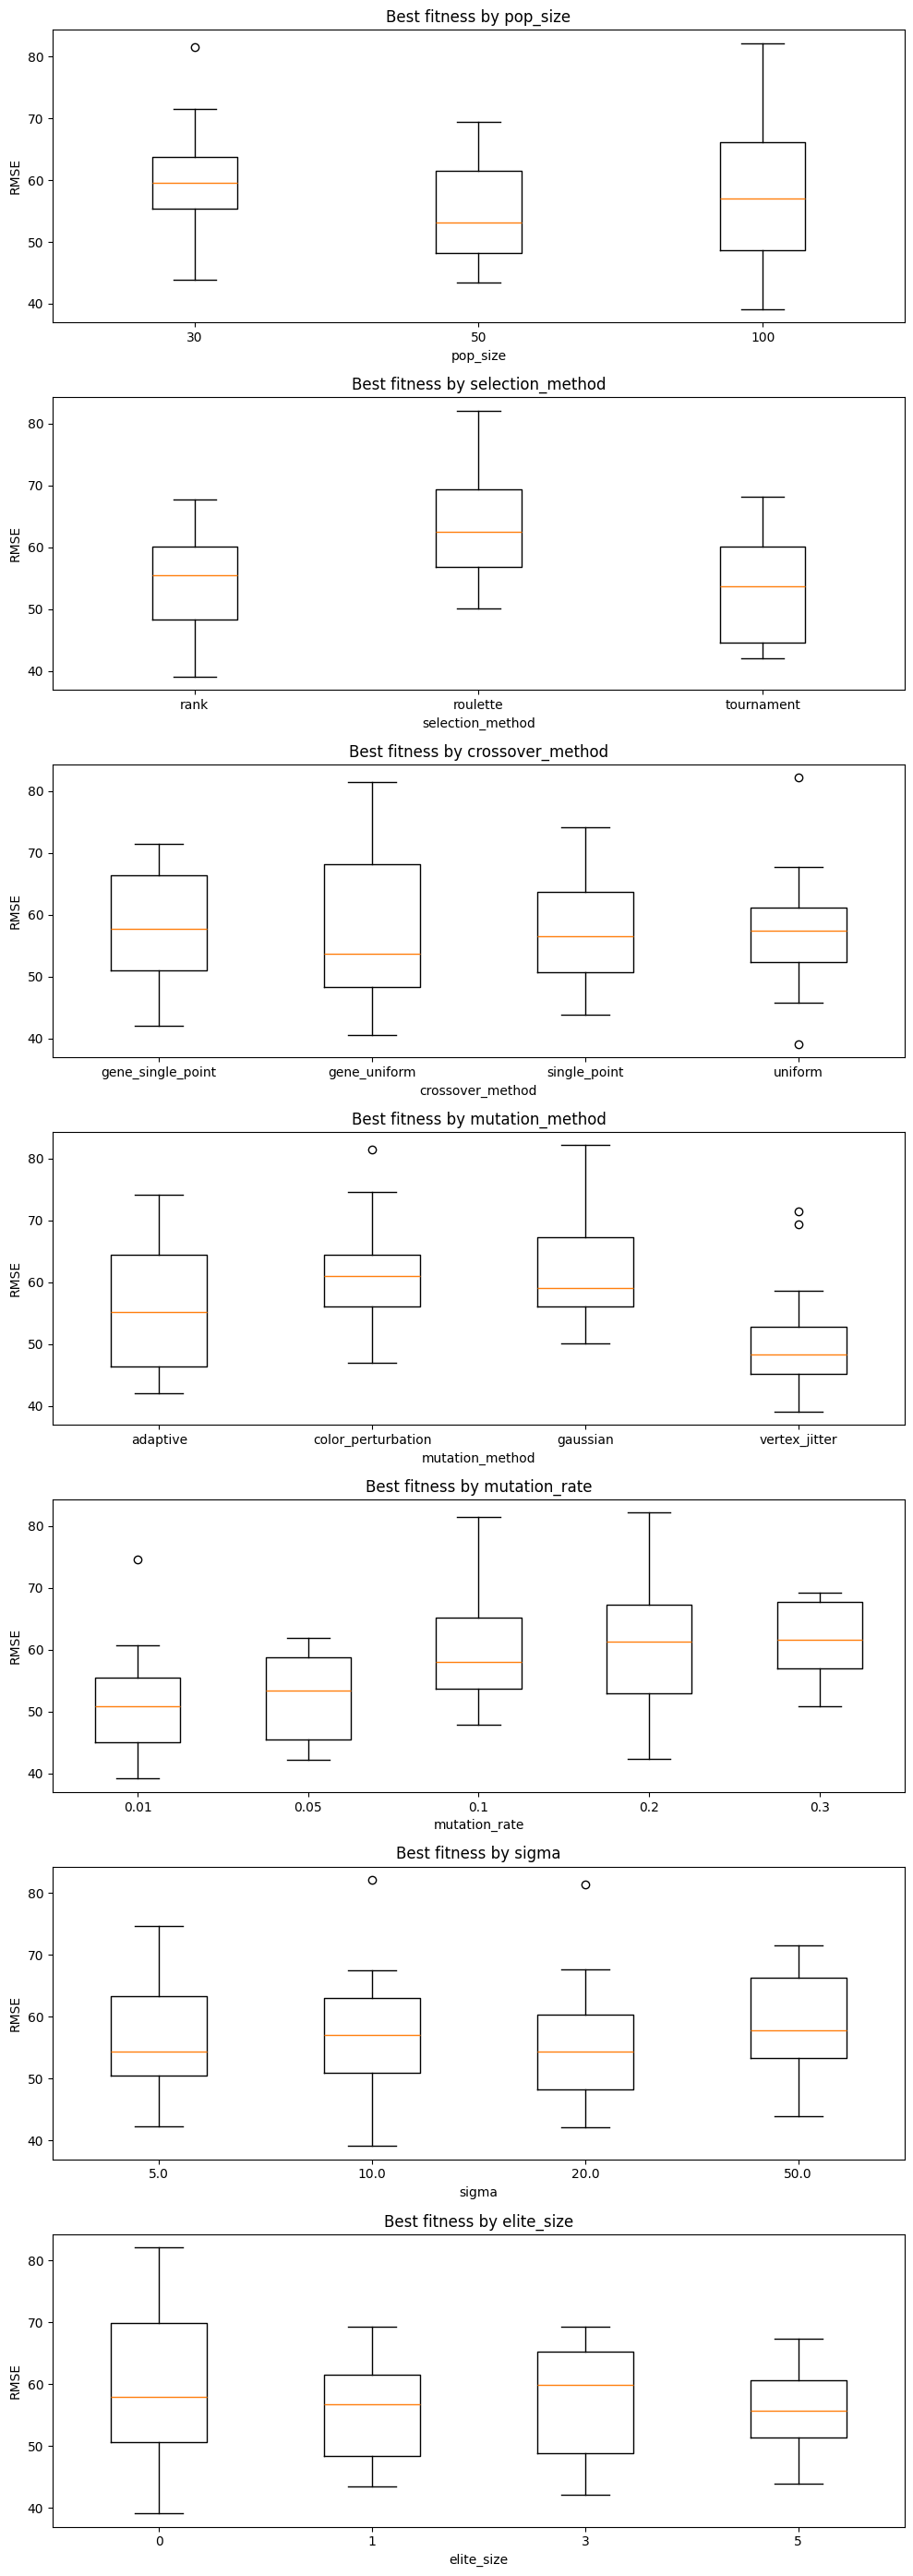

In [13]:
params = ["pop_size", "selection_method", "crossover_method",
          "mutation_method", "mutation_rate", "sigma", "elite_size"]

fig, axes = plt.subplots(len(params), 1, figsize=(10, 4 * len(params)))

for ax, param in zip(axes, params):
    groups = [group["best_fitness"].values for _, group in df.groupby(param)]
    labels = [str(k) for k in sorted(df[param].unique())]
    ax.boxplot(groups, labels=labels)
    ax.set_title(f"Best fitness by {param}")
    ax.set_ylabel("RMSE")
    ax.set_xlabel(param)

plt.tight_layout()
plt.show()

## 4. Convergence curves of top 5 runs

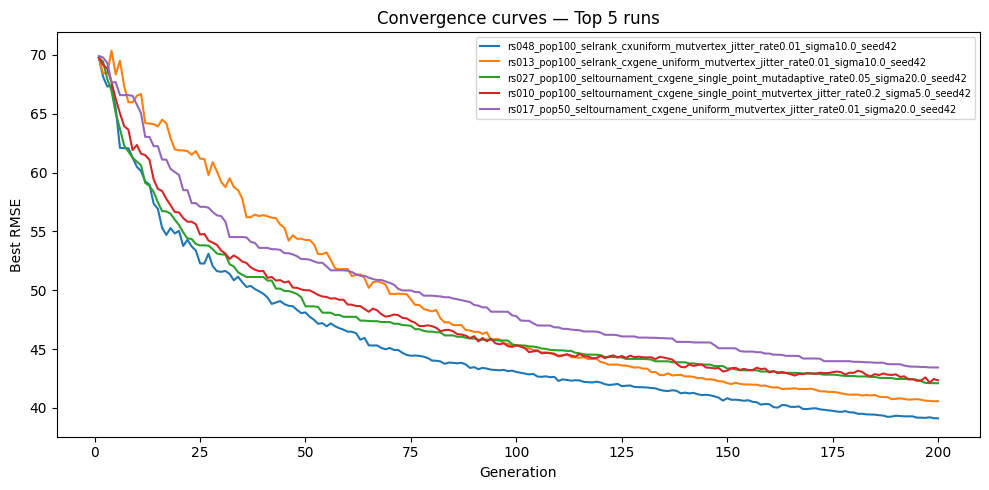

In [14]:
top5 = df.sort_values("best_fitness").head(5)

plt.figure(figsize=(10, 5))
for _, row in top5.iterrows():
    log = pd.read_csv(os.path.join(LOG_DIR, f"{row['run_id']}.csv"))
    plt.plot(log["generation"], log["best_fitness"], label=row["run_id"])

plt.xlabel("Generation")
plt.ylabel("Best RMSE")
plt.title("Convergence curves — Top 5 runs")
plt.legend(fontsize=7)
plt.tight_layout()
plt.show()

## 5. Distribution of final fitness across all runs

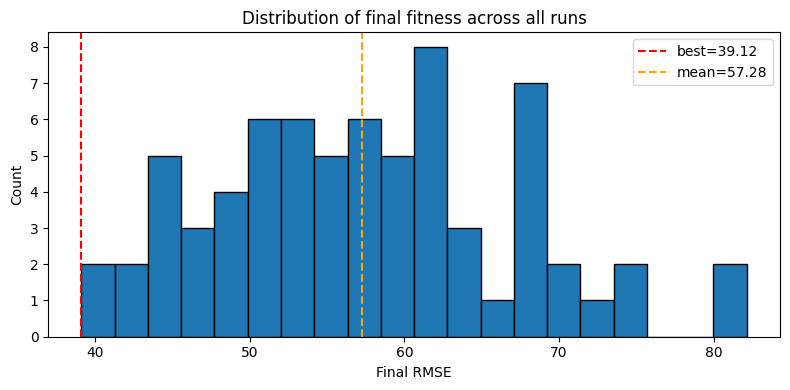

In [15]:
plt.figure(figsize=(8, 4))
plt.hist(df["best_fitness"], bins=20, edgecolor="black")
plt.axvline(df["best_fitness"].min(), color="red", linestyle="--", label=f"best={df['best_fitness'].min():.2f}")
plt.axvline(df["best_fitness"].mean(), color="orange", linestyle="--", label=f"mean={df['best_fitness'].mean():.2f}")
plt.xlabel("Final RMSE")
plt.ylabel("Count")
plt.title("Distribution of final fitness across all runs")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Mean fitness per parameter value

In [16]:
for param in params:
    print(f"\n--- {param} ---")
    print(df.groupby(param)["best_fitness"].agg(["mean", "min", "count"]).sort_values("mean"))


--- pop_size ---
               mean        min  count
pop_size                             
50        55.288761  43.436905     24
100       57.109017  39.117512     22
30        59.424687  43.907555     24

--- selection_method ---
                       mean        min  count
selection_method                             
tournament        53.317514  42.101536     22
rank              54.878936  39.117512     25
roulette          63.676626  50.158363     23

--- crossover_method ---
                        mean        min  count
crossover_method                              
uniform            56.647458  39.117512     24
single_point       57.011211  43.907555     20
gene_single_point  57.981640  42.101536     13
gene_uniform       58.153582  40.574291     13

--- mutation_method ---
                         mean        min  count
mutation_method                                
vertex_jitter       50.574209  39.117512     20
adaptive            56.416180  42.101536     12
gaussian   

## 7. Render best configuration

In [17]:
import sys
sys.path.insert(0, "..")

from src.ga import run_ga
from src.fitness import load_target
from src.rendering import render_individual

# Get best config from summary
best_row = summary.loc[df.sort_values("best_fitness").index[0]]
print("Best config:")
print(best_row.to_string())

target = load_target("../data/target.png")

best_individual, best_fitness, _ = run_ga(
    target_image=target,
    pop_size=int(best_row["pop_size"]),
    generations=int(best_row["generations"]),
    selection_method=best_row["selection_method"],
    tournament_k=int(best_row["tournament_k"]),
    crossover_method=best_row["crossover_method"],
    crossover_rate=float(best_row["crossover_rate"]),
    mutation_method=best_row["mutation_method"],
    mutation_rate=float(best_row["mutation_rate"]),
    sigma=float(best_row["sigma"]),
    elite_size=int(best_row["elite_size"]),
    seed=int(best_row["seed"]),
)

print(f"\nFinal RMSE: {best_fitness:.4f}")

Best config:
config_id                                                          48
seed                                                               42
run_id              rs048_pop100_selrank_cxuniform_mutvertex_jitte...
pop_size                                                          100
generations                                                       200
selection_method                                                 rank
tournament_k                                                        5
crossover_method                                              uniform
crossover_rate                                                    0.9
mutation_method                                         vertex_jitter
mutation_rate                                                    0.01
sigma                                                            10.0
elite_size                                                          0
Generation 1/200 | Best: 69.7657 | Avg: 79.2119
Generation 2/200 | Best: 68.1

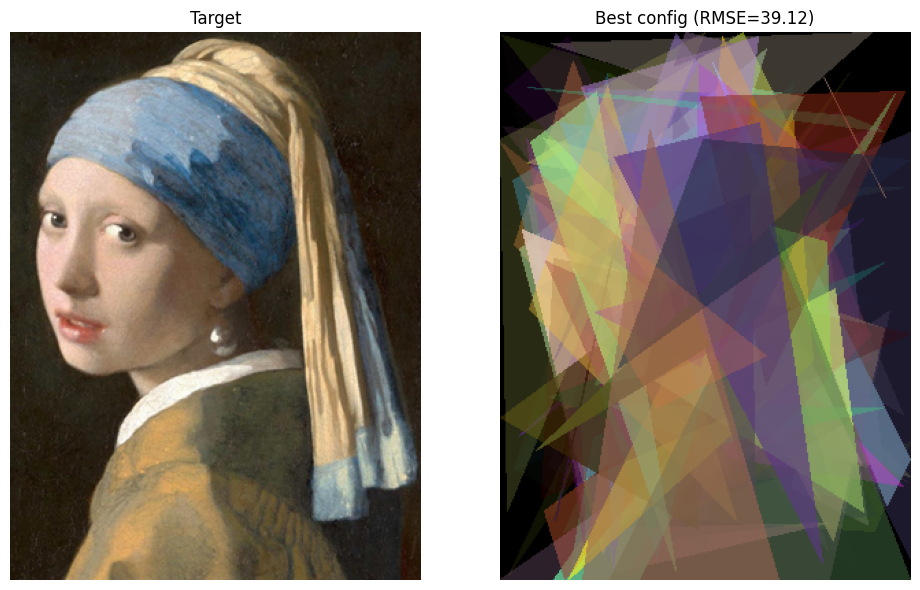

In [18]:
rendered = render_individual(best_individual)

fig, axes = plt.subplots(1, 2, figsize=(10, 6))
axes[0].imshow(target)
axes[0].set_title("Target")
axes[0].axis("off")
axes[1].imshow(rendered)
axes[1].set_title(f"Best config (RMSE={best_fitness:.2f})")
axes[1].axis("off")
plt.tight_layout()
plt.show()